# Detecção de Pneumonia por Raio-X

Este notebook tem o objetivo de implementar um modelo de **Rede Neural Convolucional (CNN)** para deteccão de imagens de raio-x do tórax, distinguindo pulmões **NORMAIS** de pulmões com **PNEUMONIA**.

O dataset utilizado é o [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) disponível no Kaggle.

# 1. Configuração do Ambiente e Download do Dataset

O dataset pode ser obtido de duas formas:
- **Via Kaggle Hub**: requer uma API key cadastrada e upload do `kaggle.json` no Colab.
- **Download manual**: baixar diretamente do Kaggle e fazer upload no ambiente.

Caso opte pelo download manual: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


Instalamos a biblioteca `kaggle`, fazemos o upload das credenciais (`kaggle.json`) e configuramos as permissões necessárias para realizar o download via linha de comando.

In [3]:
!pip install -q kaggle

from google.colab import files
import os

print("Faça o upload do seu kaggle.json:")
uploaded = files.upload()

# Configurar credenciais
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Credenciais configuradas com sucesso!")

Faça o upload do seu kaggle.json:


Saving kaggle.json to kaggle.json
Credenciais configuradas com sucesso!


### 1.1 Download do Dataset

Realizamos o download do dataset diretamente do Kaggle e descompactamos no diretório `/content/dataset`.

In [4]:
!kaggle datasets download -d "paultimothymooney/chest-xray-pneumonia" \
    --unzip -p /content/dataset

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:23<00:00, 104MB/s]



## 2. Importação de Bibliotecas

A semente aleatória (`seed = 42`) é fixada em todas as bibliotecas para garantir **reprodutibilidade** dos experimentos.

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
import random
import numpy as np

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

## 3. Carregamento do Dataset

As subpastas (`NORMAL` e `PNEUMONIA`) definem o rótulo da imagem.

> **Nota:** A pasta `val` original do dataset contém apenas **16 imagens**, o que é insuficiente para validação confiável e gera muito código para o merge com o dataset de treino. Por isso, ela é ignorada — a divisão de validação será feita a partir do próprio conjunto de treino (20%) na etapa de pré-processamento.

In [6]:
# Caminho base (ajuste conforme seu ambiente)
BASE_DIR = "/content/dataset/chest_xray"

# Caminhos principais
train_dir = os.path.join(BASE_DIR, "train")
test_dir = os.path.join(BASE_DIR, "test")

def load_dataset(path):
    imagens = []
    labels = []

    classes = ["NORMAL", "PNEUMONIA"]

    for label, classe in enumerate(classes):
        classe_path = os.path.join(path, classe)
        for arquivo in os.listdir(classe_path):
            caminho_imagem = os.path.join(classe_path, arquivo)
            imagens.append(caminho_imagem)
            labels.append(label)

    return imagens, labels

images_train, labels_train = load_dataset(train_dir)
images_test, labels_test = load_dataset(test_dir)

print("Train:", len(images_train))
print("Test:", len(images_test))

Train: 5216
Test: 624


## 4. Análise Exploratória dos Dados (EDA)

Verificamos a quantidade de imagens por classe para identificar **desbalanceamentos**.

Train (NORMAL): 1341 PNEUMONIA:  3875
Test (NORMAL): 234 PNEUMONIA:  390


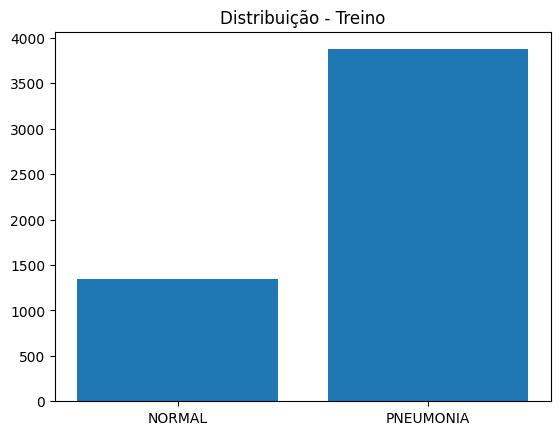

In [7]:
def class_count(labels):
    normal = sum(1 for l in labels if l == 0)
    pneumonia = sum(1 for l in labels if l == 1)
    return normal, pneumonia

train_normal, train_pneumonia = class_count(labels_train)
test_normal, test_pneumonia = class_count(labels_test)

print(f"Train (NORMAL): {train_normal} PNEUMONIA:  {train_pneumonia}")
print(f"Test (NORMAL): {test_normal} PNEUMONIA:  {test_pneumonia}")

labels_names = ['NORMAL', 'PNEUMONIA']

train_counts = [train_normal, train_pneumonia]

plt.bar(labels_names, train_counts)
plt.title("Distribuição - Treino")
plt.show()

### 4.1 Tratamento do Desbalanceamento de Classes

O dataset de treino possui mais imagens de PNEUMONIA (3.875) do que NORMAL (1.341). Se ignorado, o modelo tende a classificar tudo como PNEUMONIA e ainda assim obter alta acurácia.

Para compensar, calculamos pesos de classe com `compute_class_weight('balanced')`, que aumenta a penalização por erros na classe minoritária (NORMAL) durante o treinamento.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=labels_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


### 4.2 Visualização de Amostras

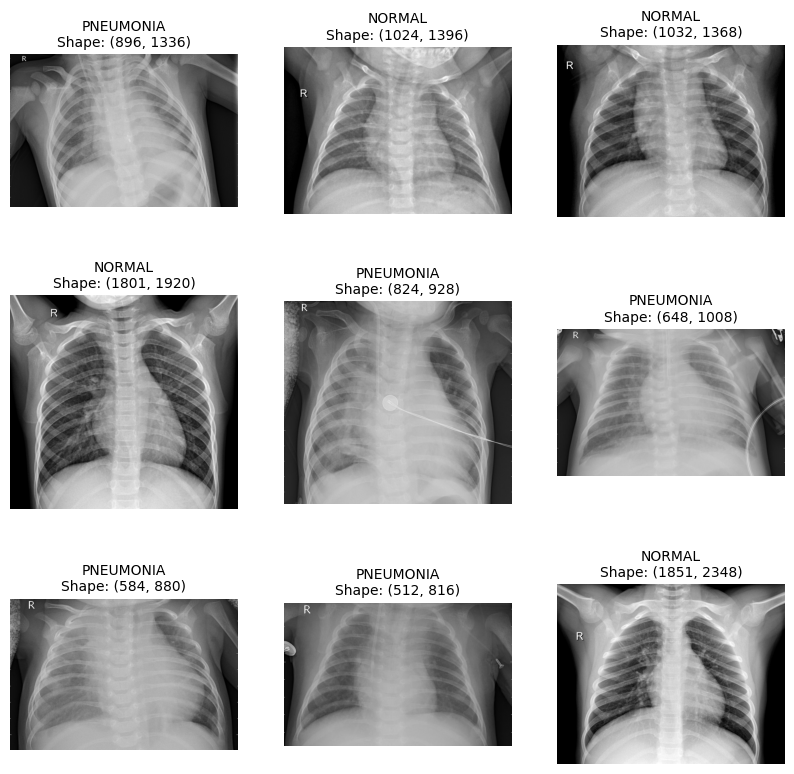

In [14]:
plt.figure(figsize=(10, 10))

for i in range(9):

    idx = random.randint(0, len(images_train)-1)

    img_path = images_train[idx]
    label = labels_train[idx]
    classe = "PNEUMONIA" if label == 1 else "NORMAL"

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{classe}\nShape: {img.shape}", fontsize=10)
    plt.axis('off')

plt.show()

As imagens originais possuem resoluções variadas e muito maiores que o necessário para treinamento.

## 5. Pré-processamento

Definimos o tamanho de entrada das imagens (`150×150 px`) e o tamanho do batch. O redimensionamento padroniza todas as imagens para a mesma resolução exigida pela CNN.

In [15]:
# Configurações para pré-processamento
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

### 5.1 Data Augmentation

- **Normalização** (`rescale=1/255`): converte os pixels de [0, 255] para [0, 1].
- **Rotação ±10°**: pequena variação angular, adequada para imagens médicas sem distorcer o diagnóstico.
- **Zoom 10%** e **deslocamentos horizontais/verticais 10%**: simulam variações naturais de posicionamento do paciente.

Para o conjunto de teste, aplicamos apenas a normalização — sem augmentation — para uma avaliação fiel ao cenário real.

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

### 5.3 Geradores de Dados

Criamos três geradores a partir dos diretórios do dataset:
- **`train_generator`**: 80% das imagens de treino com augmentation.
- **`val_generator`**: 20% das imagens de treino (sem augmentation), usado para monitorar overfitting durante o treinamento.
- **`test_generator`**: conjunto de teste original, com `shuffle=False` para garantir a correspondência correta entre predições e rótulos na avaliação final.

As imagens são carregadas em **escala de cinza** (`grayscale`).

In [18]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,  # aqui usamos o mesmo diretório de treino
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 6. Treinamento do Modelo

### 6.1 Arquitetura da CNN

Utilizamos uma CNN `Sequential` com três blocos convolucionais progressivos:

| Bloco | Camada | Filtros | Saída |
|---|---|---|---|
| 1 | Conv2D + MaxPool | 32 | 74×74×32 |
| 2 | Conv2D + MaxPool | 64 | 36×36×64 |
| 3 | Conv2D + MaxPool | 128 | 17×17×128 |

Após o `Flatten`, uma camada `Dense(128)` com **Dropout de 50%** reduz o overfitting antes da saída `sigmoid` para classificação binária.

In [19]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Conv 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Conv 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Conv 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flatten
model.add(layers.Flatten())

# Dense + Dropout
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))  # reduz overfitting

# Output
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 6.2 Callback: EarlyStopping

- **EarlyStopping**: interrompe o treino se `val_loss` não melhorar por 3 épocas consecutivas e restaura os melhores pesos encontrados.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### 6.3 Compilação do Modelo

Compilamos o modelo com:
- **Otimizador Adam**: otimizador padrão.
- **Loss `binary_crossentropy`**: adequada para classificação binária com saída sigmoid.
- **Métricas**: além da `acurácia`, monitoramos `precision`, `pecall` e `AUC`.

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

### 6.4 Execução do Treinamento

Treinamos o modelo com até **20 épocas**, usando os callbacks para controle automático de parada e learning rate, e os pesos de classe para compensar o desbalanceamento do dataset.

In [23]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 60s 411ms/step - accuracy: 0.7048 - auc: 0.8247 - loss: 0.5147 - precision: 0.9057 - recall: 0.6726 - val_accuracy: 0.8581 - val_auc: 0.9272 - val_loss: 0.3154 - val_precision: 0.9265 - val_recall: 0.8787
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 346ms/step - accuracy: 0.8608 - auc: 0.9299 - loss: 0.3439 - precision: 0.9549 - recall: 0.8529 - val_accuracy: 0.8428 - val_auc: 0.9382 - val_loss: 0.3665 - val_precision: 0.9567 - val_recall: 0.8258
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 352ms/step - accuracy: 0.8775 - auc: 0.9517 - loss: 0.2824 - precision: 0.9605 - recall: 0.8710 - val_accuracy: 0.8897 - val_auc: 0.9487 - val_loss: 0.2584 - val_precision: 0.9435 - val_recall: 0.9058
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 336ms/step - accuracy: 0.8996 - auc: 0.9612 - loss: 0.2504 - precision: 0.9699 - recall: 0.8926 - val_accuracy: 0.8773 - val_auc: 0.9702 - val_loss: 0.3094 - val_precision: 0.9879 - val_recall: 0.8452
Epoch 5/20
131/131 ━

### 6.5 Curva de Aprendizado

Plotamos as curvas de loss e accuracy ao longo das épocas para identificar visualmente:
- **Overfitting**: treino melhora continuamente mas validação piora ou estagna.
- **Underfitting**: ambas as curvas estagnadas em valor alto de loss.
- **Bom ajuste**: ambas as curvas convergem e ficam próximas.

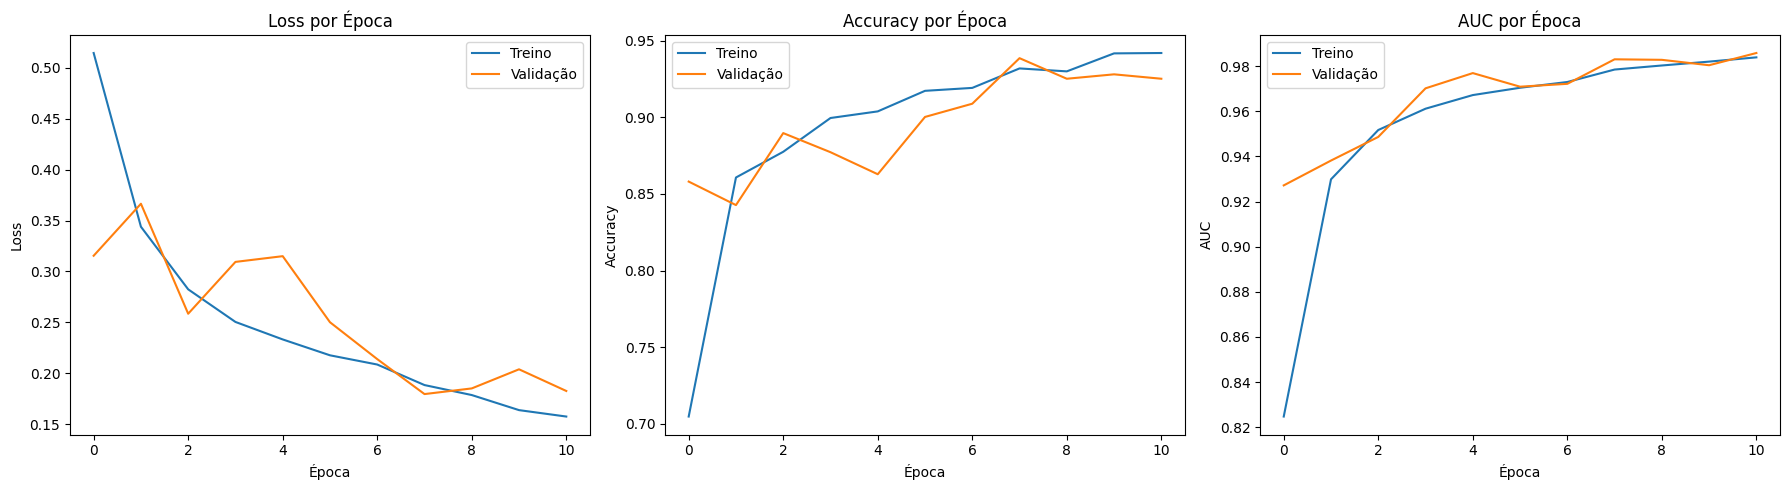

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Loss por Época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Treino')
axes[2].plot(history.history['val_auc'], label='Validação')
axes[2].set_title('AUC por Época')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Avaliação no Conjunto de Teste

Avaliamos o modelo no conjunto de teste **não visto durante o treinamento** para estimar o desempenho real em produção.

In [29]:
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(test_generator)

print(f"Loss:      {test_loss:.4f}")
print(f"Accuracy:  {test_acc * 100:.2f}%")
print(f"Precision: {test_precision * 100:.2f}%")
print(f"Recall:    {test_recall * 100:.2f}%")
print(f"AUC:       {test_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.8558 - auc: 0.9380 - loss: 0.4169 - precision: 0.8261 - recall: 0.9744
Loss:      0.4169
Accuracy:  85.58%
Precision: 82.61%
Recall:    97.44%
AUC:       0.9380


In [ ]:
Aqui temos um recall de 97% e é provavelmente a nossa métrica mais importante para o modelo.

### 7.1 Matriz de Confusão e Relatório de Classificação

A matriz de confusão mostra a distribuição de acertos e erros por classe.

Em diagnóstico médico, os **falsos negativos** (pneumonia classificada como normal) são mais críticos que os falsos positivos, pois um paciente com pneumonia não tratada corre risco de vida. Por isso, o **Recall da classe PNEUMONIA** é a métrica mais importante clinicamente.

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step


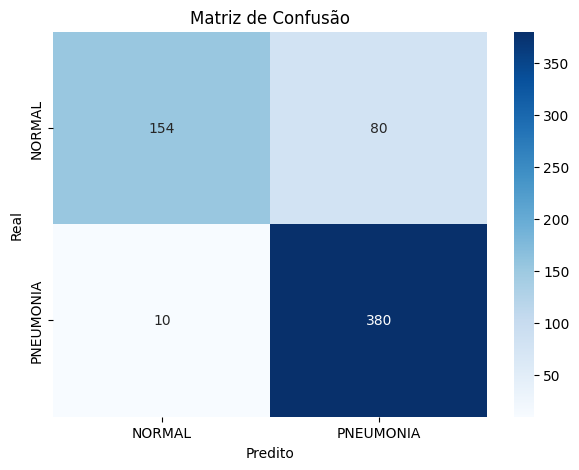

              precision    recall  f1-score   support

      NORMAL       0.94      0.66      0.77       234
   PNEUMONIA       0.83      0.97      0.89       390

    accuracy                           0.86       624
   macro avg       0.88      0.82      0.83       624
weighted avg       0.87      0.86      0.85       624



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_proba = model.predict(test_generator)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title('Matriz de Confusão')
plt.show()

print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

## 8. Salvando o Modelo

Salvamos o modelo treinado no formato `.keras` (nativo do Keras 3), que preserva a arquitetura, os pesos e a configuração do otimizador. Isso permite recarregar o modelo para inferência sem precisar retreinar.

No Colab, o `files.download()` baixa o arquivo automaticamente para a máquina local.

In [ ]:
model.save('/content/modelo_pneumonia.keras')
print("Modelo salvo em /content/modelo_pneumonia.keras")

# Download automático no Colab
from google.colab import files
files.download('/content/modelo_pneumonia.keras')